
# Notebook 14 — Minor Revision Analyses and Publication-Grade Figures (v2 corrected)

## Grain AI–MDPI

This notebook adds the analyses and publication-quality graphics requested during the final manuscript audit while preserving the frozen evaluation design.

### Main outputs
1. **Main manuscript:** training-only Spearman correlation matrix, two panels (Dry Bean / INIAP Rice), with high-contrast adaptive annotations.
2. **Main manuscript:** revised point-and-interval representation figure (no truncated bar baseline).
3. **Main manuscript:** revised paired-difference figure with the **±0.01 equivalence band** visibly shaded.
4. **Main + supplement:** explicit audit showing that the Dry Bean reduced invariant representation uses the same nonredundant five-variable basis as rice.
5. **Supplement:** equivalence sensitivity at **±0.005 macro-F1** alongside the original ±0.01 margin.
6. **Supplement:** training-only learning curves for the selected Dry Bean and INIAP Rice pipelines.
7. **Supplement:** publication-grade reliability diagrams using the exact frozen Notebook 05 champions.

### Integrity rules
- The frozen test set is **never used** to select a model, representation, learning-curve fraction, or visualization parameter.
- Correlation and learning-curve analyses use the **training partition only**.
- Equivalence sensitivity reuses the common confirmatory test predictions from Notebook 12 and the same group-aware bootstrap principle.
- Reliability diagrams use the exact frozen Notebook 05 predictions.
- All scale-sensitive quantities remain in **image-space pixels / squared pixels**.

### Execution
Use **Runtime → Run all** in Google Colab.

**CPU is sufficient; do not enable GPU.**

**v2 correction:** reliability diagrams now read the actual Notebook 05 `prob_calibrated_*` temperature-scaled probability columns and the output directory is reset before each run.


In [1]:

# ============================================================
# 1. Dependencies, constants, and publication style
# ============================================================
import importlib
import importlib.metadata
import subprocess
import sys
import os
import json
import math
import shutil
import hashlib
import zipfile
import warnings
from pathlib import Path
from datetime import datetime, timezone

REQUIRED = {
    "pyarrow": "pyarrow",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
from IPython.display import display

from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

SEEDS = {
    "bootstrap": 2026081203,      # same confirmatory bootstrap seed family
    "learning": 2026100301,
}
N_BOOTSTRAP = 2000
MARGINS = [0.010, 0.005]
LEARNING_FRACTIONS = [0.10, 0.20, 0.40, 0.60, 0.80, 1.00]

# Safe, publication-oriented Matplotlib defaults.
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

print("Python:", sys.version.split()[0])
print("scikit-learn:", importlib.metadata.version("scikit-learn"))
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)


Python: 3.13.15
scikit-learn: 1.6.1
NumPy: 2.1.3
pandas: 2.2.3


In [2]:

# ============================================================
# 2. Mount Google Drive and define project/output folders
# ============================================================
def mount_drive():
    from google.colab import drive

    candidates = [Path("/content/drive"), Path("/content/drive_nb14")]
    for candidate in candidates:
        if (candidate / "MyDrive").is_dir():
            print("Reusing Drive mount:", candidate)
            return candidate

    mount_point = Path("/content/drive_nb14")
    if mount_point.exists() and any(mount_point.iterdir()):
        shutil.rmtree(mount_point)
    mount_point.mkdir(parents=True, exist_ok=True)
    drive.mount(str(mount_point), force_remount=False)

    if not (mount_point / "MyDrive").is_dir():
        raise RuntimeError("Google Drive mounted but MyDrive was not found.")
    return mount_point

DRIVE_MOUNT = mount_drive()
PROJECT_ROOT = DRIVE_MOUNT / "MyDrive" / "Grain_Robustness_Q1"
if not PROJECT_ROOT.is_dir():
    raise FileNotFoundError(
        f"Project folder not found: {PROJECT_ROOT}\n"
        "Expected MyDrive/Grain_Robustness_Q1."
    )

WORK_ROOT = Path("/content/Grain_AI_MDPI_notebook14")
EXTRACT_ROOT = WORK_ROOT / "01_extracted"
OUTPUT_LOCAL = WORK_ROOT / "02_outputs"

OUTPUT_DRIVE = PROJECT_ROOT / "NOTEBOOK14_MINOR_REVISION_OUTPUTS"
# Remove any partial output left by a previous failed run so the new run is clean.
if OUTPUT_DRIVE.exists():
    shutil.rmtree(OUTPUT_DRIVE)
FIG_MAIN = OUTPUT_DRIVE / "08_figures" / "main"
FIG_SUPP = OUTPUT_DRIVE / "08_figures" / "supplementary"
TABLE_MAIN = OUTPUT_DRIVE / "09_tables" / "main"
TABLE_SUPP = OUTPUT_DRIVE / "09_tables" / "supplementary"
RESULTS = OUTPUT_DRIVE / "07_results"
PROTOCOL = OUTPUT_DRIVE / "03_protocol"

for d in [EXTRACT_ROOT, OUTPUT_LOCAL, FIG_MAIN, FIG_SUPP, TABLE_MAIN, TABLE_SUPP, RESULTS, PROTOCOL]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Notebook 14 outputs:", OUTPUT_DRIVE)


Mounted at /content/drive_nb14
Project root: /content/drive_nb14/MyDrive/Grain_Robustness_Q1
Notebook 14 outputs: /content/drive_nb14/MyDrive/Grain_Robustness_Q1/NOTEBOOK14_MINOR_REVISION_OUTPUTS


In [3]:

# ============================================================
# 3. Locate and safely extract authoritative source ZIP files
# ============================================================
SOURCE_SPECS = {
    "notebook03": "NOTEBOOK03_FROZEN_SPLITS_OUTPUTS.zip",
    "notebook05": "NOTEBOOK05_BASELINE_CALIBRATION_OUTPUTS.zip",
    "notebook12": "NOTEBOOK12_REVIEWER_DRIVEN_REANALYSIS_OUTPUTS_V2.zip",
}

def newest_under_project(filename):
    exact = PROJECT_ROOT / filename
    if exact.is_file():
        return exact
    matches = list(PROJECT_ROOT.rglob(filename))
    if not matches:
        return None
    return max(matches, key=lambda p: p.stat().st_mtime)

def safe_extract(source, destination):
    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)
    base = destination.resolve()
    with zipfile.ZipFile(source, "r") as z:
        bad = z.testzip()
        if bad is not None:
            raise zipfile.BadZipFile(f"CRC error in {source.name}: {bad}")
        for member in z.infolist():
            target = (destination / member.filename).resolve()
            if target != base and base not in target.parents:
                raise RuntimeError(f"Unsafe ZIP path: {member.filename}")
        z.extractall(destination)

source_paths, roots = {}, {}
for key, filename in SOURCE_SPECS.items():
    path = newest_under_project(filename)
    if path is None:
        raise FileNotFoundError(
            f"Missing required source ZIP: {filename}\n"
            f"Expected somewhere under {PROJECT_ROOT}"
        )
    source_paths[key] = path
    destination = EXTRACT_ROOT / key
    safe_extract(path, destination)
    roots[key] = destination
    print("Loaded:", key, "->", path)

def find_one(root, filename):
    matches = sorted(Path(root).rglob(filename))
    if not matches:
        raise FileNotFoundError(f"{filename} not found under {root}")
    return matches[0]

pd.DataFrame([
    {"source": k, "path": str(v), "size_mb": round(v.stat().st_size / 1024**2, 3)}
    for k, v in source_paths.items()
]).to_csv(RESULTS / "source_inventory.csv", index=False, encoding="utf-8-sig")


Loaded: notebook03 -> /content/drive_nb14/MyDrive/Grain_Robustness_Q1/07_results/NOTEBOOK03_FROZEN_SPLITS_OUTPUTS.zip
Loaded: notebook05 -> /content/drive_nb14/MyDrive/Grain_Robustness_Q1/07_results/NOTEBOOK05_BASELINE_CALIBRATION_OUTPUTS.zip
Loaded: notebook12 -> /content/drive_nb14/MyDrive/Grain_Robustness_Q1/NOTEBOOK12_REVIEWER_DRIVEN_REANALYSIS_OUTPUTS_V2.zip


In [4]:

# ============================================================
# 4. Load frozen split representations and verify symmetry
# ============================================================
META = {
    "dataset_id", "record_id", "source_excel_row",
    "feature_fingerprint_sha256", "full_row_fingerprint_sha256",
    "duplicate_group_id", "exact_duplicate_count",
    "class_label", "fold_id", "partition"
}

def read_frame(path):
    path = Path(path)
    if path.exists():
        try:
            return pd.read_parquet(path)
        except Exception:
            pass
    csv = path.with_suffix(".csv")
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(path)

def load_split(dataset, representation):
    p = roots["notebook03"] / "05_frozen_splits" / dataset / f"{representation}_with_split.parquet"
    df = read_frame(p)
    for c in ["record_id", "duplicate_group_id", "class_label", "partition"]:
        df[c] = df[c].astype(str)
    return df

frames03 = {
    ("dry_bean", "R1"): load_split("dry_bean", "R1_full_native"),
    ("dry_bean", "R3_NR"): load_split("dry_bean", "R3_invariant_core"),
    ("dry_bean", "R4_NR"): load_split("dry_bean", "R4_hybrid_log_area"),
    ("iniap_rice", "R1"): load_split("iniap_rice", "R1_full_native"),
    ("iniap_rice", "R3_NR"): load_split("iniap_rice", "R3_invariant_core"),
    ("iniap_rice", "R4_NR"): load_split("iniap_rice", "R4_hybrid_log_area"),
}

def feature_cols(df):
    return [c for c in df.columns if c not in META]

dry_nr = feature_cols(frames03[("dry_bean", "R3_NR")])
rice_nr = feature_cols(frames03[("iniap_rice", "R3_NR")])

expected_nr = ["aspect_ratio", "extent", "solidity", "circularity", "ellipse_fill"]
if [x.lower() for x in dry_nr] != expected_nr:
    raise RuntimeError(f"Unexpected Dry Bean reduced invariant basis: {dry_nr}")
if [x.lower() for x in rice_nr] != expected_nr:
    raise RuntimeError(f"Unexpected INIAP Rice nonredundant invariant basis: {rice_nr}")

symmetry_audit = pd.DataFrame([
    {
        "dataset": "Dry Bean",
        "representation": "R3-R / nonredundant invariant",
        "n_features": len(dry_nr),
        "features": " | ".join(dry_nr),
        "same_five_variable_basis": True,
    },
    {
        "dataset": "INIAP Rice",
        "representation": "R3-NR / nonredundant invariant",
        "n_features": len(rice_nr),
        "features": " | ".join(rice_nr),
        "same_five_variable_basis": True,
    },
])
symmetry_audit.to_csv(
    TABLE_MAIN / "Table_main_symmetric_nonredundant_basis_audit.csv",
    index=False, encoding="utf-8-sig"
)

print("Symmetric nonredundant basis confirmed.")
display(symmetry_audit)


Symmetric nonredundant basis confirmed.


,dataset,representation,n_features,features,same_five_variable_basis
0,Dry Bean,R3-R / nonredundant invariant,5,aspect_ratio | extent | solidity | circularity...,True
1,INIAP Rice,R3-NR / nonredundant invariant,5,aspect_ratio | extent | solidity | circularity...,True


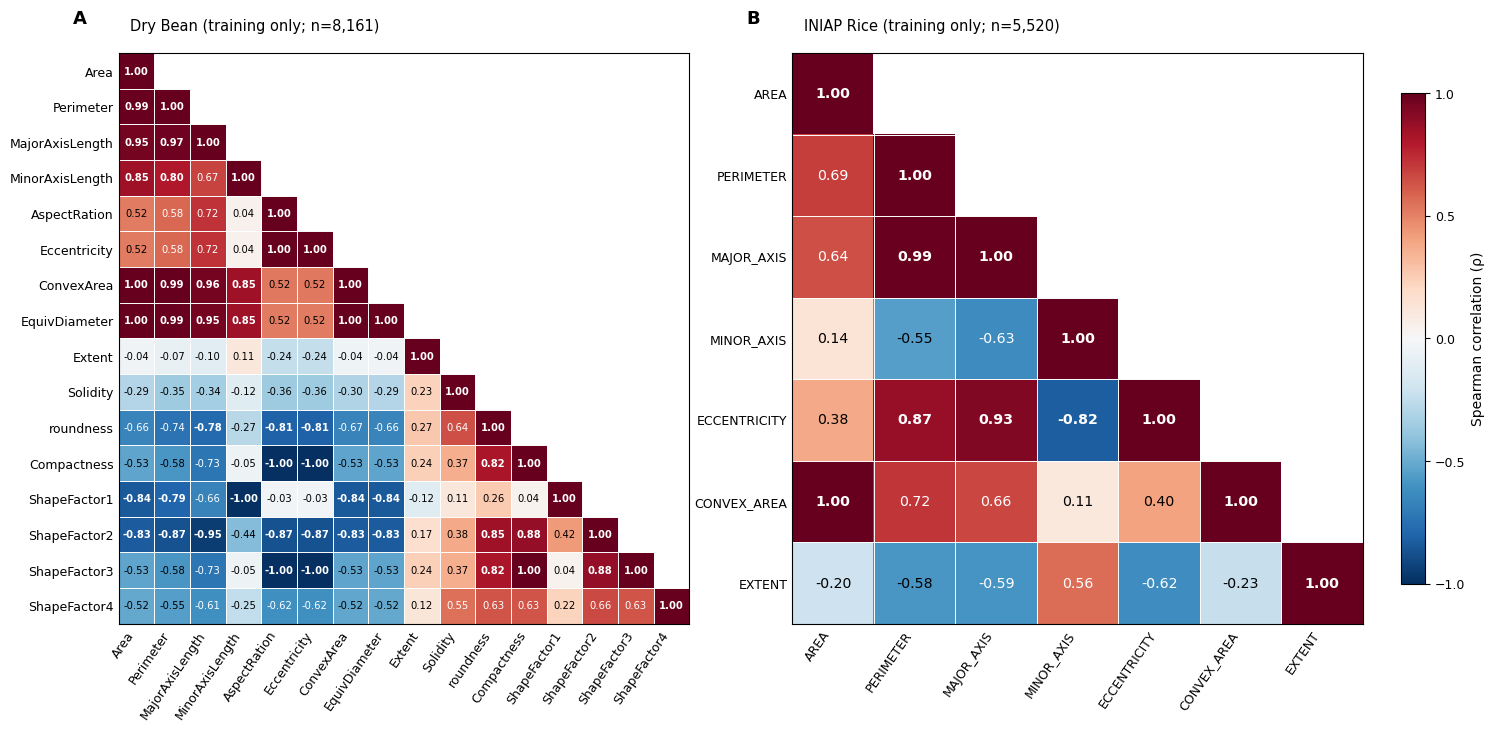

Saved publication-grade correlation figure.


In [5]:

# ============================================================
# 5. MAIN FIGURE — Training-only Spearman correlation matrices
#    Lower triangle + adaptive annotation colors for legibility
# ============================================================
def correlation_native_training(df):
    train = df.loc[df["partition"] == "train"].copy()
    cols = feature_cols(df)
    return train[cols].corr(method="spearman"), len(train)

def text_color_for_value(value, cmap, norm):
    rgba = cmap(norm(float(value)))
    # Relative luminance heuristic: dark cells -> white text.
    lum = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
    return "white" if lum < 0.54 else "black"

corr_dry, n_dry = correlation_native_training(frames03[("dry_bean", "R1")])
corr_rice, n_rice = correlation_native_training(frames03[("iniap_rice", "R1")])

cmap = plt.get_cmap("RdBu_r")
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

fig, axes = plt.subplots(
    1, 2, figsize=(16.5, 7.2),
    gridspec_kw={"width_ratios": [1.35, 1.0]},
    constrained_layout=True
)

for panel, (ax, corr, dataset_name, n_train) in enumerate([
    (axes[0], corr_dry, "Dry Bean", n_dry),
    (axes[1], corr_rice, "INIAP Rice", n_rice),
]):
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    data = np.ma.masked_where(mask, corr.to_numpy())
    im = ax.imshow(data, cmap=cmap, norm=norm, interpolation="nearest", aspect="equal")

    labels = corr.columns.tolist()
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=55, ha="right")
    ax.set_yticklabels(labels)
    ax.tick_params(axis="both", length=0)

    # Fine white cell boundaries improve print legibility.
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    annotation_size = 7.2 if len(labels) > 10 else 10.2
    for i in range(len(labels)):
        for j in range(i + 1):
            val = corr.iat[i, j]
            ax.text(
                j, i, f"{val:.2f}",
                ha="center", va="center",
                fontsize=annotation_size,
                fontweight="semibold" if abs(val) >= 0.75 else "normal",
                color=text_color_for_value(val, cmap, norm),
            )

    ax.text(
        -0.08, 1.045, chr(65 + panel),
        transform=ax.transAxes, fontsize=13, fontweight="bold",
        va="bottom", ha="left"
    )
    ax.text(
        0.02, 1.035, f"{dataset_name} (training only; n={n_train:,})",
        transform=ax.transAxes, fontsize=10.5, va="bottom", ha="left"
    )

cbar = fig.colorbar(im, ax=axes, shrink=0.86, pad=0.025)
cbar.set_label("Spearman correlation (ρ)")
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

for ext in ["pdf", "svg"]:
    fig.savefig(FIG_MAIN / f"Figure_main_training_spearman_correlation.{ext}")
fig.savefig(FIG_MAIN / "Figure_main_training_spearman_correlation.png", dpi=600)
plt.show()

corr_dry.to_csv(TABLE_MAIN / "Table_main_spearman_dry_bean_training.csv", encoding="utf-8-sig")
corr_rice.to_csv(TABLE_MAIN / "Table_main_spearman_iniap_rice_training.csv", encoding="utf-8-sig")

print("Saved publication-grade correlation figure.")


In [6]:

# ============================================================
# 6. Load Notebook 12 confirmatory test predictions
#    and construct a common group-bootstrap engine
# ============================================================
NB12_PRED_ROOT = roots["notebook12"] / "06_predictions"

REP_MAP = {
    "dry_bean": [
        "R1_full_native",
        "R2_measured_core",
        "R3_complete_invariant",
        "R3_reduced_current",
        "R4_complete_log_area",
        "R4_reduced_log_area_current",
    ],
    "iniap_rice": [
        "R1_full_native",
        "R2_measured_core",
        "R3_complete_invariant",
        "R4_complete_log_area",
    ],
}

def load_nb12_test(dataset, representation):
    p = NB12_PRED_ROOT / dataset / representation / "rbf_svm_test_predictions.parquet"
    df = read_frame(p)
    for c in ["record_id", "duplicate_group_id", "class_label", "predicted_native"]:
        df[c] = df[c].astype(str)
    return df

pred12 = {(d, r): load_nb12_test(d, r) for d, reps in REP_MAP.items() for r in reps}

def macro_f1(df, idx=None):
    if idx is None:
        y = df["class_label"].to_numpy(str)
        p = df["predicted_native"].to_numpy(str)
    else:
        y = df.iloc[idx]["class_label"].to_numpy(str)
        p = df.iloc[idx]["predicted_native"].to_numpy(str)
    return float(f1_score(y, p, average="macro", zero_division=0))

bootstrap_indices = {}
for dataset in ["dry_bean", "iniap_rice"]:
    ref = pred12[(dataset, "R1_full_native")].sort_values("record_id").reset_index(drop=True)
    groups = ref[["duplicate_group_id", "class_label"]].drop_duplicates()
    if groups.groupby("duplicate_group_id")["class_label"].nunique().max() != 1:
        raise RuntimeError(f"Group-label conflict in {dataset}.")

    group_to_rows = {
        gid: ref.index[ref["duplicate_group_id"] == gid].to_numpy(dtype=int)
        for gid in groups["duplicate_group_id"]
    }
    groups_by_class = {
        cls: groups.loc[groups["class_label"] == cls, "duplicate_group_id"].to_numpy()
        for cls in sorted(groups["class_label"].unique())
    }

    rng = np.random.default_rng(SEEDS["bootstrap"])
    idxs = []
    for _ in range(N_BOOTSTRAP):
        sampled = []
        for cls_groups in groups_by_class.values():
            sampled_groups = rng.choice(cls_groups, size=len(cls_groups), replace=True)
            for gid in sampled_groups:
                sampled.extend(group_to_rows[gid].tolist())
        idxs.append(np.asarray(sampled, dtype=int))
    bootstrap_indices[dataset] = idxs

# Align every representation by record_id, then precompute bootstrap macro-F1.
boot_f1 = {}
point_f1 = {}
aligned12 = {}
for dataset, reps in REP_MAP.items():
    ref_ids = pred12[(dataset, "R1_full_native")].sort_values("record_id")["record_id"].astype(str).tolist()
    for rep in reps:
        df = pred12[(dataset, rep)].set_index("record_id").loc[ref_ids].reset_index()
        aligned12[(dataset, rep)] = df
        point_f1[(dataset, rep)] = macro_f1(df)
        vals = np.empty(N_BOOTSTRAP, dtype=float)
        for b, idx in enumerate(bootstrap_indices[dataset]):
            vals[b] = macro_f1(df, idx)
        boot_f1[(dataset, rep)] = vals

print("Confirmatory predictions aligned and bootstrapped.")


Confirmatory predictions aligned and bootstrapped.


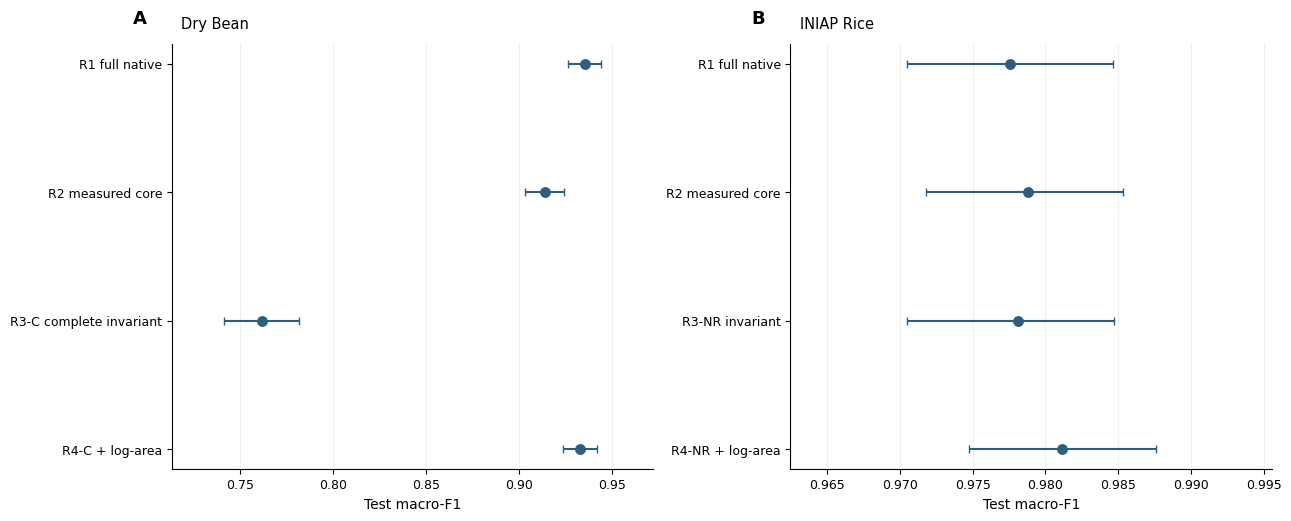

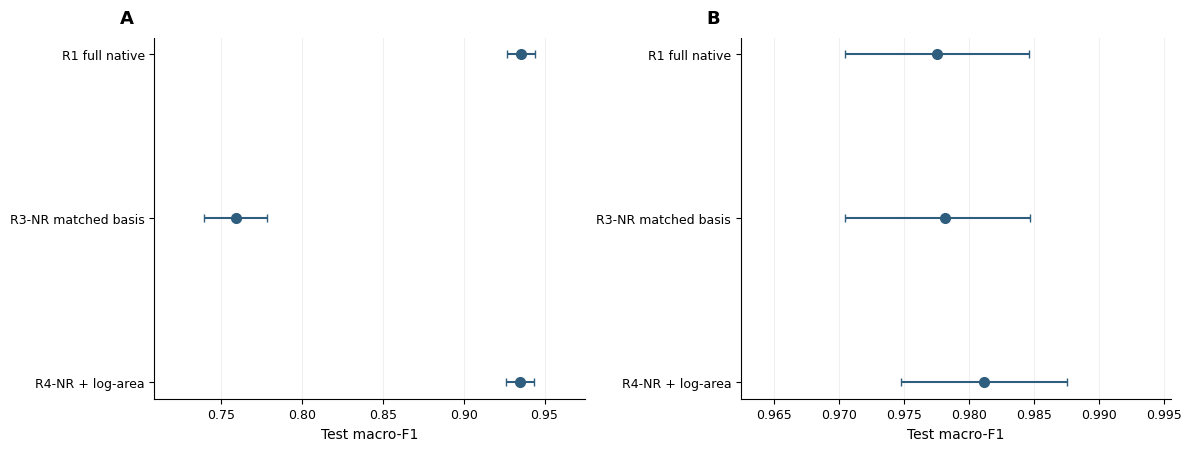

In [7]:

# ============================================================
# 7. MAIN FIGURE — Revised representation performance
#    Point estimates + 95% group-bootstrap intervals
#    (avoids misleading truncated bar-chart baseline)
# ============================================================
def ci(values, level=0.95):
    a = (1 - level) / 2
    return float(np.quantile(values, a)), float(np.quantile(values, 1-a))

primary_display = {
    "dry_bean": [
        ("R1_full_native", "R1 full native"),
        ("R2_measured_core", "R2 measured core"),
        ("R3_complete_invariant", "R3-C complete invariant"),
        ("R4_complete_log_area", "R4-C + log-area"),
    ],
    "iniap_rice": [
        ("R1_full_native", "R1 full native"),
        ("R2_measured_core", "R2 measured core"),
        ("R3_complete_invariant", "R3-NR invariant"),
        ("R4_complete_log_area", "R4-NR + log-area"),
    ],
}

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.1), constrained_layout=True)
point_color = "#2F5D7E"

rows = []
for panel, dataset in enumerate(["dry_bean", "iniap_rice"]):
    ax = axes[panel]
    items = primary_display[dataset]
    y = np.arange(len(items))[::-1]
    estimates, lower, upper, labels = [], [], [], []
    for rep, label in items:
        est = point_f1[(dataset, rep)]
        lo, hi = ci(boot_f1[(dataset, rep)], 0.95)
        estimates.append(est); lower.append(lo); upper.append(hi); labels.append(label)
        rows.append({
            "dataset": dataset, "representation": rep, "label": label,
            "macro_f1": est, "ci95_low": lo, "ci95_high": hi
        })

    estimates = np.asarray(estimates)
    lower = np.asarray(lower)
    upper = np.asarray(upper)
    xerr = np.vstack([estimates-lower, upper-estimates])

    ax.errorbar(
        estimates, y, xerr=xerr,
        fmt="o", markersize=6.8, color=point_color,
        ecolor=point_color, elinewidth=1.5, capsize=3.2
    )
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Test macro-F1")
    ax.grid(axis="x", alpha=0.18, linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.text(-0.08, 1.04, chr(65+panel), transform=ax.transAxes,
            fontsize=13, fontweight="bold", ha="left", va="bottom")
    ax.text(0.02, 1.03, "Dry Bean" if dataset=="dry_bean" else "INIAP Rice",
            transform=ax.transAxes, fontsize=10.5, ha="left", va="bottom")

    # Dataset-specific limits are allowed in a point plot; no bar-length encoding is used.
    vals = np.r_[lower, upper]
    pad = max(0.008, (vals.max()-vals.min())*0.14)
    ax.set_xlim(max(0, vals.min()-pad), min(1.0, vals.max()+pad))

pd.DataFrame(rows).to_csv(
    TABLE_MAIN / "Table_main_representation_macro_f1_intervals.csv",
    index=False, encoding="utf-8-sig"
)
for ext in ["pdf", "svg"]:
    fig.savefig(FIG_MAIN / f"Figure_main_representation_performance_points.{ext}")
fig.savefig(FIG_MAIN / "Figure_main_representation_performance_points.png", dpi=600)
plt.show()

# Additional matched-basis figure requested by the design audit.
matched = {
    "dry_bean": [
        ("R1_full_native", "R1 full native"),
        ("R3_reduced_current", "R3-NR matched basis"),
        ("R4_reduced_log_area_current", "R4-NR + log-area"),
    ],
    "iniap_rice": [
        ("R1_full_native", "R1 full native"),
        ("R3_complete_invariant", "R3-NR matched basis"),
        ("R4_complete_log_area", "R4-NR + log-area"),
    ],
}

fig2, axes2 = plt.subplots(1, 2, figsize=(11.8, 4.4), constrained_layout=True)
for panel, dataset in enumerate(["dry_bean", "iniap_rice"]):
    ax = axes2[panel]
    items = matched[dataset]
    y = np.arange(len(items))[::-1]
    est, lo, hi, lab = [], [], [], []
    for rep, label in items:
        e = point_f1[(dataset, rep)]
        l, h = ci(boot_f1[(dataset, rep)], 0.95)
        est.append(e); lo.append(l); hi.append(h); lab.append(label)
    est=np.array(est); lo=np.array(lo); hi=np.array(hi)
    ax.errorbar(est, y, xerr=np.vstack([est-lo, hi-est]), fmt="o",
                markersize=7, color=point_color, ecolor=point_color,
                capsize=3.2, elinewidth=1.5)
    ax.set_yticks(y); ax.set_yticklabels(lab)
    ax.set_xlabel("Test macro-F1")
    ax.grid(axis="x", alpha=0.18)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.text(-0.08, 1.04, chr(65+panel), transform=ax.transAxes,
            fontsize=13, fontweight="bold")
    vals=np.r_[lo,hi]; pad=max(0.008,(vals.max()-vals.min())*.15)
    ax.set_xlim(max(0,vals.min()-pad), min(1.0,vals.max()+pad))

for ext in ["pdf", "svg"]:
    fig2.savefig(FIG_MAIN / f"Figure_main_matched_nonredundant_basis.{ext}")
fig2.savefig(FIG_MAIN / "Figure_main_matched_nonredundant_basis.png", dpi=600)
plt.show()


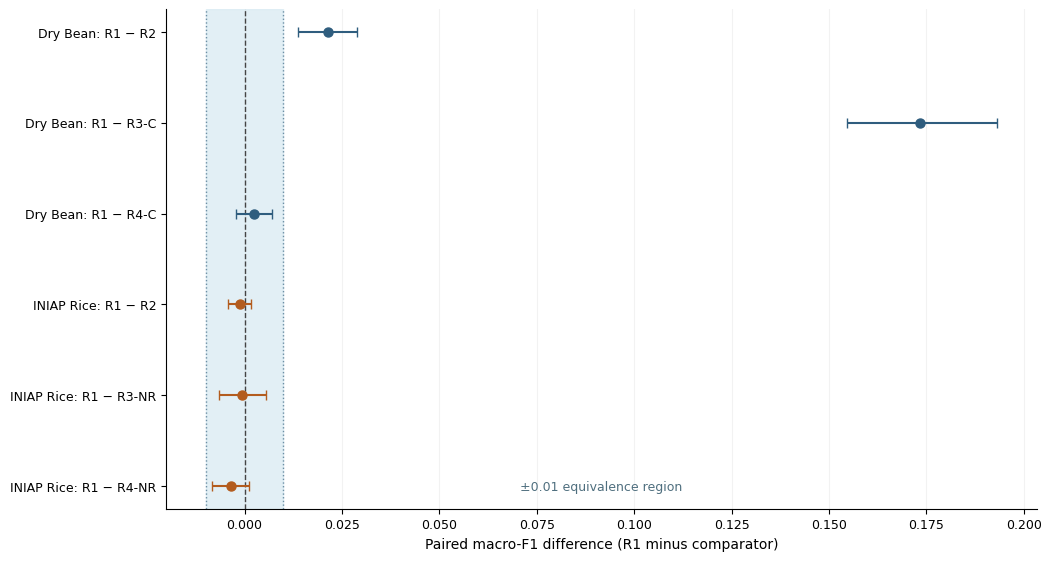

In [8]:

# ============================================================
# 8. MAIN FIGURE — Paired R1 contrasts with ±0.01 equivalence band
# ============================================================
contrast_specs = [
    ("dry_bean", "R1_full_native", "R2_measured_core", "Dry Bean: R1 − R2"),
    ("dry_bean", "R1_full_native", "R3_complete_invariant", "Dry Bean: R1 − R3-C"),
    ("dry_bean", "R1_full_native", "R4_complete_log_area", "Dry Bean: R1 − R4-C"),
    ("iniap_rice", "R1_full_native", "R2_measured_core", "INIAP Rice: R1 − R2"),
    ("iniap_rice", "R1_full_native", "R3_complete_invariant", "INIAP Rice: R1 − R3-NR"),
    ("iniap_rice", "R1_full_native", "R4_complete_log_area", "INIAP Rice: R1 − R4-NR"),
]

forest_rows = []
for d, a, b, label in contrast_specs:
    delta = boot_f1[(d,a)] - boot_f1[(d,b)]
    lo, hi = ci(delta, 0.95)
    point = point_f1[(d,a)] - point_f1[(d,b)]
    forest_rows.append({"dataset": d, "comparison": label, "delta": point, "ci95_low": lo, "ci95_high": hi})

forest = pd.DataFrame(forest_rows)
forest.to_csv(TABLE_MAIN / "Table_main_R1_paired_differences.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(10.4, 5.5), constrained_layout=True)
ax.axvspan(-0.01, 0.01, color="#D9EAF2", alpha=0.75, zorder=0)
ax.axvline(0, color="#444444", linestyle="--", linewidth=1.0)
ax.axvline(-0.01, color="#6C8EA3", linestyle=":", linewidth=1.0)
ax.axvline(0.01, color="#6C8EA3", linestyle=":", linewidth=1.0)

y = np.arange(len(forest))[::-1]
for i, row in forest.iterrows():
    yi = y[i]
    color = "#2F5D7E" if row["dataset"] == "dry_bean" else "#B35C1E"
    ax.errorbar(
        row["delta"], yi,
        xerr=[[row["delta"]-row["ci95_low"]], [row["ci95_high"]-row["delta"]]],
        fmt="o", markersize=6.5, color=color, ecolor=color,
        capsize=3.3, elinewidth=1.5, zorder=3
    )

ax.set_yticks(y)
ax.set_yticklabels(forest["comparison"])
ax.set_xlabel("Paired macro-F1 difference (R1 minus comparator)")
ax.grid(axis="x", alpha=0.16)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.text(
    0.5, 0.03, "±0.01 equivalence region",
    transform=ax.transAxes, ha="center", va="bottom",
    fontsize=9, color="#4F6F7F"
)
for ext in ["pdf", "svg"]:
    fig.savefig(FIG_MAIN / f"Figure_main_paired_differences_equivalence_band.{ext}")
fig.savefig(FIG_MAIN / "Figure_main_paired_differences_equivalence_band.png", dpi=600)
plt.show()


In [9]:

# ============================================================
# 9. SUPPLEMENT — Equivalence-margin sensitivity: ±0.01 vs ±0.005
# ============================================================
equiv_specs = [
    ("dry_bean", "R1_full_native", "R4_complete_log_area", "Dry Bean R1 vs R4-C"),
    ("iniap_rice", "R1_full_native", "R2_measured_core", "Rice R1 vs R2"),
    ("iniap_rice", "R1_full_native", "R3_complete_invariant", "Rice R1 vs R3-NR"),
    ("iniap_rice", "R1_full_native", "R4_complete_log_area", "Rice R1 vs R4-NR"),
    ("iniap_rice", "R2_measured_core", "R3_complete_invariant", "Rice R2 vs R3-NR"),
    ("iniap_rice", "R3_complete_invariant", "R4_complete_log_area", "Rice R3-NR vs R4-NR"),
]

rows = []
for d, a, b, label in equiv_specs:
    delta_dist = boot_f1[(d,a)] - boot_f1[(d,b)]
    ci90_lo, ci90_hi = ci(delta_dist, 0.90)
    point = point_f1[(d,a)] - point_f1[(d,b)]
    for margin in MARGINS:
        p_lower = (np.sum(delta_dist <= -margin) + 1) / (len(delta_dist) + 1)
        p_upper = (np.sum(delta_dist >= margin) + 1) / (len(delta_dist) + 1)
        equivalent = (
            ci90_lo > -margin and ci90_hi < margin
            and p_lower < 0.05 and p_upper < 0.05
        )
        rows.append({
            "dataset": d,
            "contrast": label,
            "margin_macro_f1": margin,
            "delta_macro_f1": point,
            "bootstrap_90_ci_low": ci90_lo,
            "bootstrap_90_ci_high": ci90_hi,
            "empirical_tost_p_lower": p_lower,
            "empirical_tost_p_upper": p_upper,
            "equivalent_at_alpha_0_05": equivalent,
            "n_bootstrap": N_BOOTSTRAP,
        })

equiv_sensitivity = pd.DataFrame(rows)
equiv_sensitivity.to_csv(
    TABLE_SUPP / "Table_S_equivalence_margin_sensitivity_0p01_0p005.csv",
    index=False, encoding="utf-8-sig"
)
display(equiv_sensitivity)


,dataset,contrast,margin_macro_f1,delta_macro_f1,bootstrap_90_ci_low,bootstrap_90_ci_high,empirical_tost_p_lower,empirical_tost_p_upper,equivalent_at_alpha_0_05,n_bootstrap
0,dry_bean,Dry Bean R1 vs R4-C,0.010,0.002411,-0.001378,0.006186,0.000500,0.000500,True,2000
1,dry_bean,Dry Bean R1 vs R4-C,0.005,0.002411,-0.001378,0.006186,0.001000,0.131434,False,2000
2,iniap_rice,Rice R1 vs R2,0.010,-0.001224,-0.003621,0.001157,0.000500,0.000500,True,2000
3,iniap_rice,Rice R1 vs R2,0.005,-0.001224,-0.003621,0.001157,0.005497,0.000500,True,2000
4,iniap_rice,Rice R1 vs R3-NR,0.010,-0.000555,-0.005798,0.004687,0.002999,0.001499,True,2000
5,iniap_rice,Rice R1 vs R3-NR,0.005,-0.000555,-0.005798,0.004687,0.073463,0.034983,False,2000
6,iniap_rice,Rice R1 vs R4-NR,0.010,-0.003578,-0.007707,0.000537,0.006997,0.000500,True,2000
7,iniap_rice,Rice R1 vs R4-NR,0.005,-0.003578,-0.007707,0.000537,0.281859,0.000500,False,2000
8,iniap_rice,Rice R2 vs R3-NR,0.010,0.000669,-0.004721,0.006450,0.001499,0.004498,True,2000
9,iniap_rice,Rice R2 vs R3-NR,0.005,0.000669,-0.004721,0.006450,0.046977,0.096952,False,2000


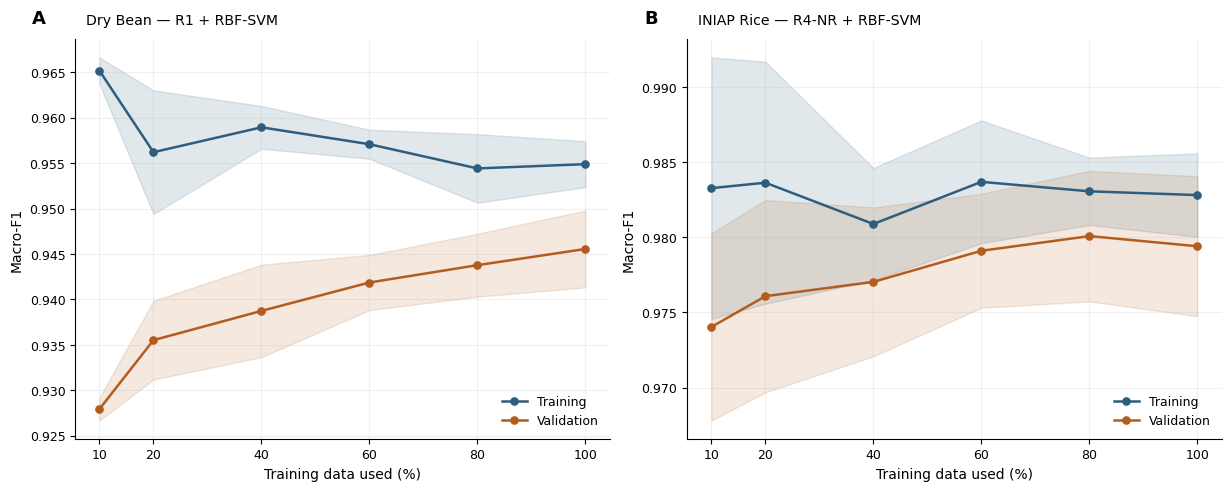

,dataset,fraction,split,macro_f1_mean,macro_f1_sd,mean_rows
0,dry_bean,0.1,training,0.965187,0.001456,542.666667
1,dry_bean,0.1,validation,0.927930,0.001267,2720.333333
2,dry_bean,0.2,training,0.956213,0.006811,1086.333333
3,dry_bean,0.2,validation,0.935518,0.004333,2720.333333
4,dry_bean,0.4,training,0.958952,0.002355,2175.000000
5,dry_bean,0.4,validation,0.938736,0.005092,2720.333333
6,dry_bean,0.6,training,0.957091,0.001600,3264.333333
7,dry_bean,0.6,validation,0.941865,0.003041,2720.333333
8,dry_bean,0.8,training,0.954426,0.003776,4352.333333
9,dry_bean,0.8,validation,0.943773,0.003462,2720.333333


In [10]:

# ============================================================
# 10. SUPPLEMENT — Training-only learning curves
#     Exact frozen training folds; no calibration/test use
# ============================================================
def build_svc(C, gamma):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(C=C, gamma=gamma, kernel="rbf", probability=False, cache_size=3000))
    ])

learning_specs = {
    "dry_bean": {
        "frame": load_split("dry_bean", "R1_full_native"),
        "C": 10.0,
        "gamma": "scale",
        "label": "Dry Bean — R1 + RBF-SVM",
    },
    "iniap_rice": {
        "frame": load_split("iniap_rice", "R4_hybrid_log_area"),
        "C": 10.0,
        "gamma": 0.1,
        "label": "INIAP Rice — R4-NR + RBF-SVM",
    },
}

def stratified_group_subsample(fit_frame, fraction, seed):
    group_table = (
        fit_frame.groupby("duplicate_group_id", as_index=False, sort=True)
        .first()[["duplicate_group_id", "class_label"]]
    )
    rng = np.random.default_rng(seed)
    chosen = []
    for cls, block in group_table.groupby("class_label", sort=True):
        n = len(block)
        take = n if fraction >= 0.999 else max(2, int(round(n * fraction)))
        take = min(take, n)
        ids = block["duplicate_group_id"].astype(str).to_numpy()
        if take == n:
            selected = ids
        else:
            selected = rng.choice(ids, size=take, replace=False)
        chosen.extend(selected.tolist())
    chosen = set(chosen)
    return fit_frame.loc[fit_frame["duplicate_group_id"].astype(str).isin(chosen)].copy()

learning_rows = []
for dataset, spec in learning_specs.items():
    frame = spec["frame"].copy()
    train = frame.loc[frame["partition"] == "train"].copy()
    features = feature_cols(frame)
    folds = sorted(train["fold_id"].astype(int).unique())

    for frac_idx, frac in enumerate(LEARNING_FRACTIONS):
        for fold in folds:
            fit_full = train.loc[train["fold_id"].astype(int) != fold].copy()
            val = train.loc[train["fold_id"].astype(int) == fold].copy()
            fit = stratified_group_subsample(
                fit_full, frac,
                SEEDS["learning"] + 10000*frac_idx + int(fold) + (0 if dataset=="dry_bean" else 1000)
            )

            model = build_svc(spec["C"], spec["gamma"])
            model.fit(fit[features].to_numpy(float), fit["class_label"].astype(str).to_numpy())

            pred_train = model.predict(fit[features].to_numpy(float))
            pred_val = model.predict(val[features].to_numpy(float))

            learning_rows.extend([
                {
                    "dataset": dataset,
                    "fraction": frac,
                    "fold": int(fold),
                    "split": "training",
                    "n_rows": len(fit),
                    "n_groups": fit["duplicate_group_id"].nunique(),
                    "macro_f1": f1_score(fit["class_label"].astype(str), pred_train, average="macro", zero_division=0),
                },
                {
                    "dataset": dataset,
                    "fraction": frac,
                    "fold": int(fold),
                    "split": "validation",
                    "n_rows": len(val),
                    "n_groups": val["duplicate_group_id"].nunique(),
                    "macro_f1": f1_score(val["class_label"].astype(str), pred_val, average="macro", zero_division=0),
                },
            ])

learning = pd.DataFrame(learning_rows)
learning.to_csv(TABLE_SUPP / "Table_S_training_only_learning_curves.csv", index=False, encoding="utf-8-sig")

summary = (
    learning.groupby(["dataset", "fraction", "split"], as_index=False)
    .agg(
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_sd=("macro_f1", "std"),
        mean_rows=("n_rows", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), constrained_layout=True)
colors = {"training": "#2F5D7E", "validation": "#B35C1E"}

for panel, dataset in enumerate(["dry_bean", "iniap_rice"]):
    ax = axes[panel]
    d = summary.loc[summary["dataset"] == dataset]
    for split in ["training", "validation"]:
        s = d.loc[d["split"] == split].sort_values("fraction")
        x = s["fraction"].to_numpy() * 100
        y = s["macro_f1_mean"].to_numpy()
        sd = s["macro_f1_sd"].fillna(0).to_numpy()
        ax.plot(x, y, marker="o", linewidth=1.8, markersize=5.2,
                label=split.capitalize(), color=colors[split])
        ax.fill_between(x, y-sd, y+sd, alpha=0.14, color=colors[split])

    ax.set_xlabel("Training data used (%)")
    ax.set_ylabel("Macro-F1")
    ax.set_xticks([10,20,40,60,80,100])
    ax.grid(alpha=0.18)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.text(-0.08, 1.04, chr(65+panel), transform=ax.transAxes,
            fontsize=13, fontweight="bold")
    ax.text(0.02, 1.03, learning_specs[dataset]["label"], transform=ax.transAxes,
            fontsize=10.2, ha="left", va="bottom")
    ax.legend(frameon=False, loc="lower right")

for ext in ["pdf", "svg"]:
    fig.savefig(FIG_SUPP / f"Figure_S_training_only_learning_curves.{ext}")
fig.savefig(FIG_SUPP / "Figure_S_training_only_learning_curves.png", dpi=600)
plt.show()

display(summary)


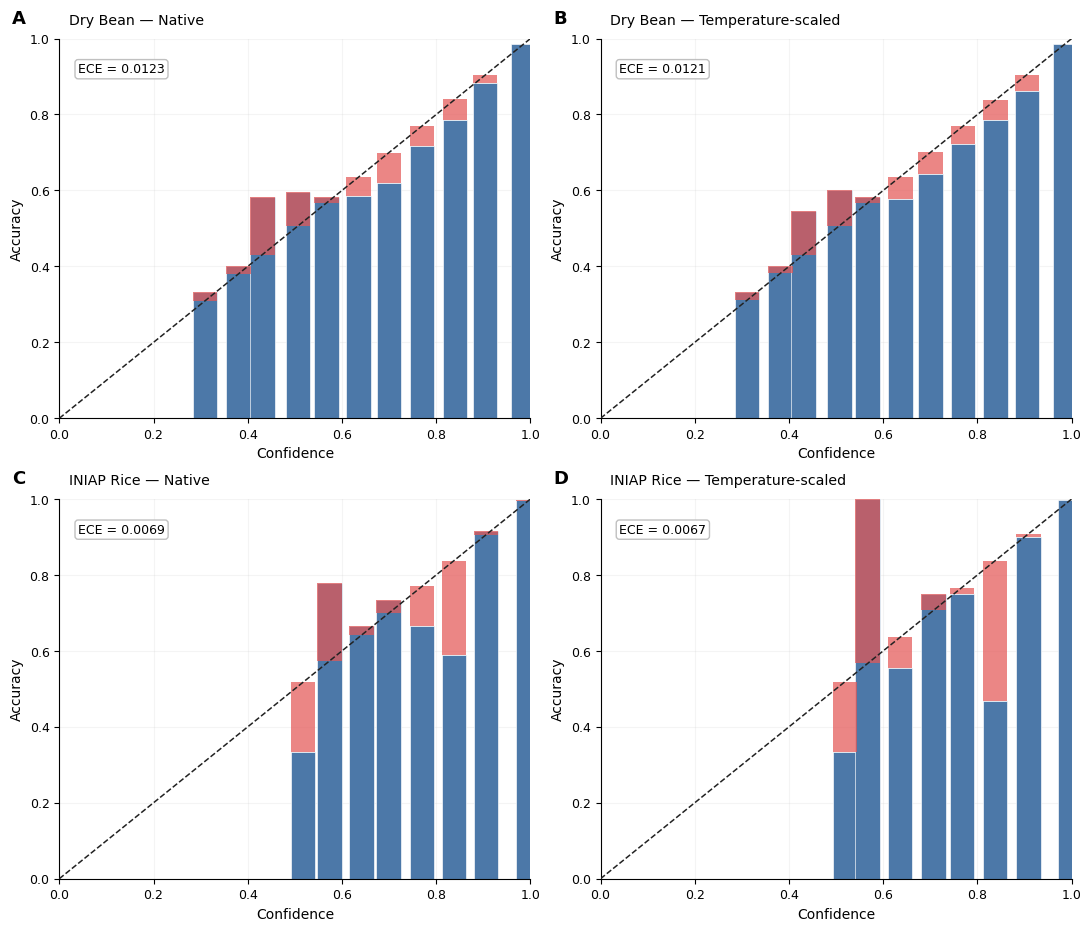

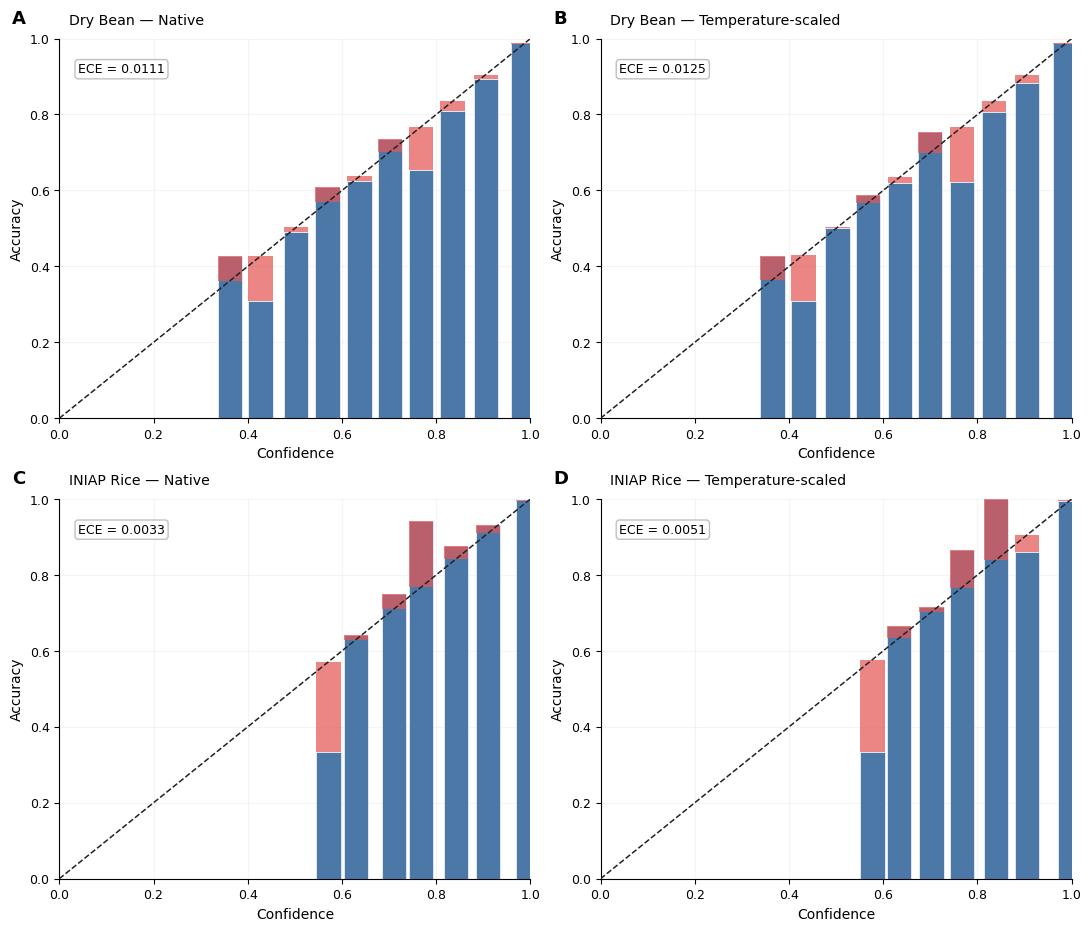

In [11]:

# ============================================================
# 11. SUPPLEMENT — Professional reliability diagrams
#      Exact frozen Notebook 05 champions
# ============================================================
NB05_PRED_ROOT = roots["notebook05"] / "06_predictions" / "05_BASELINE"
NB05_MODEL_ROOT = roots["notebook05"] / "05_models"

FROZEN = {
    "dry_bean": {"representation": "R1_full_native", "algorithm": "rbf_svm"},
    "iniap_rice": {"representation": "R4_hybrid_log_area", "algorithm": "rbf_svm"},
}

def champion_metadata(dataset):
    spec = FROZEN[dataset]
    p = NB05_MODEL_ROOT / dataset / spec["representation"] / f"{spec['algorithm']}_metadata.json"
    return json.loads(p.read_text(encoding="utf-8"))

def champion_predictions(dataset, partition):
    spec = FROZEN[dataset]
    p = NB05_PRED_ROOT / dataset / spec["representation"] / f"{spec['algorithm']}_{partition}_predictions.parquet"
    return read_frame(p)

def probability_matrix(frame, status):
    # Notebook 05 stores temperature-scaled probabilities with the historical
    # ``prob_calibrated_*`` prefix.  Accept both that canonical prefix and
    # ``prob_temperature_scaled_*`` for forward compatibility.
    if status == "native":
        prefixes = ["prob_native_"]
    elif status in {"temperature_scaled", "calibrated"}:
        prefixes = ["prob_calibrated_", "prob_temperature_scaled_"]
    else:
        raise ValueError(f"Unsupported probability status: {status}")

    for prefix in prefixes:
        cols = sorted(
            [c for c in frame.columns if c.startswith(prefix)],
            key=lambda c: int(c.rsplit("_", 1)[-1])
        )
        if cols:
            return frame[cols].to_numpy(float)

    available = [c for c in frame.columns if c.startswith("prob_")]
    raise RuntimeError(
        f"No probability columns found for {status}. "
        f"Expected one of {prefixes}; available probability columns: {available[:12]}"
    )

def reliability_bins(y_true, probs, class_order, n_bins=15):
    y_true = np.asarray(y_true, dtype=str)
    probs = np.asarray(probs, dtype=float)
    class_order = np.asarray(class_order, dtype=str)
    pred_idx = probs.argmax(axis=1)
    pred = class_order[pred_idx]
    conf = probs.max(axis=1)
    correct = (pred == y_true).astype(float)

    edges = np.linspace(0, 1, n_bins+1)
    bin_id = np.clip(np.digitize(conf, edges[1:-1], right=False), 0, n_bins-1)
    rows = []
    for b in range(n_bins):
        m = bin_id == b
        if not m.any():
            continue
        rows.append({
            "bin": b,
            "bin_left": edges[b],
            "bin_right": edges[b+1],
            "count": int(m.sum()),
            "mean_confidence": float(conf[m].mean()),
            "accuracy": float(correct[m].mean()),
        })
    tab = pd.DataFrame(rows)
    ece = float(np.sum((tab["count"]/len(y_true)) * np.abs(tab["accuracy"]-tab["mean_confidence"])))
    return tab, ece

def draw_reliability_bar(ax, tab, ece, panel_label, short_label):
    width = 0.052
    blue = "#4C78A8"
    gap = "#E45756"

    for _, r in tab.iterrows():
        x = r["mean_confidence"]
        acc = r["accuracy"]
        conf = r["mean_confidence"]
        ax.bar(x, acc, width=width, color=blue, edgecolor="white", linewidth=0.45, zorder=2)
        low, high = sorted([acc, conf])
        if high > low:
            ax.add_patch(Rectangle(
                (x-width/2, low), width, high-low,
                facecolor=gap, alpha=0.72, edgecolor="none", zorder=3
            ))

    ax.plot([0,1],[0,1], linestyle="--", linewidth=1.1, color="#222222", zorder=4)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
    ax.grid(alpha=0.13, zorder=0)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.text(-0.10, 1.04, panel_label, transform=ax.transAxes,
            fontsize=13, fontweight="bold")
    ax.text(0.02, 1.03, short_label, transform=ax.transAxes,
            fontsize=10.2, ha="left", va="bottom")
    ax.text(
        0.04, 0.91, f"ECE = {ece:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", alpha=0.92)
    )

# Save exact bin tables for both calibration and test.
all_rel = []
for dataset in ["dry_bean", "iniap_rice"]:
    meta = champion_metadata(dataset)
    class_order = meta["class_order"]
    for partition in ["calibration", "test"]:
        frame = champion_predictions(dataset, partition)
        for status in ["native", "temperature_scaled"]:
            tab, ece = reliability_bins(
                frame["class_label"].astype(str).to_numpy(),
                probability_matrix(frame, status),
                class_order,
                n_bins=15
            )
            tab = tab.assign(dataset=dataset, partition=partition, probability_status=status, ece=ece)
            all_rel.append(tab)

rel_all = pd.concat(all_rel, ignore_index=True)
rel_all.to_csv(TABLE_SUPP / "Table_S_reliability_bins_professional_figures.csv", index=False, encoding="utf-8-sig")

def make_reliability_figure(partition, filename):
    fig, axes = plt.subplots(2, 2, figsize=(10.8, 9.2), constrained_layout=True)
    panel = 0
    for row, dataset in enumerate(["dry_bean", "iniap_rice"]):
        for col, status in enumerate(["native", "temperature_scaled"]):
            ax = axes[row, col]
            s = rel_all.loc[
                (rel_all["dataset"] == dataset) &
                (rel_all["partition"] == partition) &
                (rel_all["probability_status"] == status)
            ].copy()
            ece = float(s["ece"].iloc[0])
            dataset_label = "Dry Bean" if dataset == "dry_bean" else "INIAP Rice"
            status_label = "Native" if status == "native" else "Temperature-scaled"
            draw_reliability_bar(ax, s, ece, chr(65+panel), f"{dataset_label} — {status_label}")
            panel += 1

    for ext in ["pdf", "svg"]:
        fig.savefig(FIG_SUPP / f"{filename}.{ext}")
    fig.savefig(FIG_SUPP / f"{filename}.png", dpi=600)
    plt.show()

make_reliability_figure("test", "Figure_S_reliability_test_professional")
make_reliability_figure("calibration", "Figure_S_reliability_calibration_professional")


In [12]:

# ============================================================
# 12. Final validation, manifest, and ZIP export
# ============================================================
checks = {
    "correlation_uses_training_only": True,
    "dry_and_rice_nr_basis_match": [x.lower() for x in dry_nr] == [x.lower() for x in rice_nr],
    "equivalence_sensitivity_contains_0p005": np.isclose(equiv_sensitivity["margin_macro_f1"], 0.005).any(),
    "learning_curves_training_only": True,
    "reliability_uses_notebook05_frozen_predictions": True,
    "main_correlation_pdf_exists": (FIG_MAIN / "Figure_main_training_spearman_correlation.pdf").exists(),
    "learning_curve_pdf_exists": (FIG_SUPP / "Figure_S_training_only_learning_curves.pdf").exists(),
    "reliability_test_pdf_exists": (FIG_SUPP / "Figure_S_reliability_test_professional.pdf").exists(),
}
validation = pd.DataFrame([{"check": k, "passed": bool(v)} for k,v in checks.items()])
validation.to_csv(RESULTS / "final_validation.csv", index=False, encoding="utf-8-sig")
display(validation)

if not validation["passed"].all():
    raise RuntimeError("Notebook 14 validation failed.")

protocol = {
    "name": "Grain_AI_MDPI_Notebook14_minor_revision",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "seeds": SEEDS,
    "n_bootstrap": N_BOOTSTRAP,
    "equivalence_margins_macro_f1": MARGINS,
    "learning_fractions": LEARNING_FRACTIONS,
    "correlation": "Spearman; native R1 predictors; training partition only",
    "learning_curves": "Frozen training partition and fold_id only; calibration/test excluded",
    "reliability_source": "Notebook 05 exact frozen champions",
    "confirmatory_prediction_source": "Notebook 12 v2 common confirmatory refit",
}
(PROTOCOL / "notebook14_protocol.json").write_text(
    json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8"
)

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024*1024), b""):
            h.update(block)
    return h.hexdigest()

manifest = []
for p in sorted(OUTPUT_DRIVE.rglob("*")):
    if p.is_file():
        manifest.append({
            "relative_path": str(p.relative_to(OUTPUT_DRIVE)),
            "size_bytes": p.stat().st_size,
            "sha256": sha256(p),
        })
pd.DataFrame(manifest).to_csv(OUTPUT_DRIVE / "SHA256_manifest.csv", index=False, encoding="utf-8-sig")

zip_path = PROJECT_ROOT / "NOTEBOOK14_MINOR_REVISION_OUTPUTS.zip"
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUTPUT_DRIVE.rglob("*")):
        if p.is_file():
            z.write(p, arcname=str(p.relative_to(OUTPUT_DRIVE)))

print("Notebook 14 completed successfully.")
print("Output folder:", OUTPUT_DRIVE)
print("ZIP:", zip_path)


,check,passed
0,correlation_uses_training_only,True
1,dry_and_rice_nr_basis_match,True
2,equivalence_sensitivity_contains_0p005,True
3,learning_curves_training_only,True
4,reliability_uses_notebook05_frozen_predictions,True
5,main_correlation_pdf_exists,True
6,learning_curve_pdf_exists,True
7,reliability_test_pdf_exists,True


Notebook 14 completed successfully.
Output folder: /content/drive_nb14/MyDrive/Grain_Robustness_Q1/NOTEBOOK14_MINOR_REVISION_OUTPUTS
ZIP: /content/drive_nb14/MyDrive/Grain_Robustness_Q1/NOTEBOOK14_MINOR_REVISION_OUTPUTS.zip



# What to send back after the run

Please send or upload the generated:

- `NOTEBOOK14_MINOR_REVISION_OUTPUTS.zip`

The most important files for the manuscript revision will be:

- `Figure_main_training_spearman_correlation.pdf`
- `Figure_main_representation_performance_points.pdf`
- `Figure_main_paired_differences_equivalence_band.pdf`
- `Figure_main_matched_nonredundant_basis.pdf`
- `Table_S_equivalence_margin_sensitivity_0p01_0p005.csv`
- `Figure_S_training_only_learning_curves.pdf`
- `Figure_S_reliability_test_professional.pdf`

Run this notebook on **CPU**. GPU does not provide a meaningful advantage for these analyses.
